# Mesh Analysis

Solve the following circuit using mesh analysis:

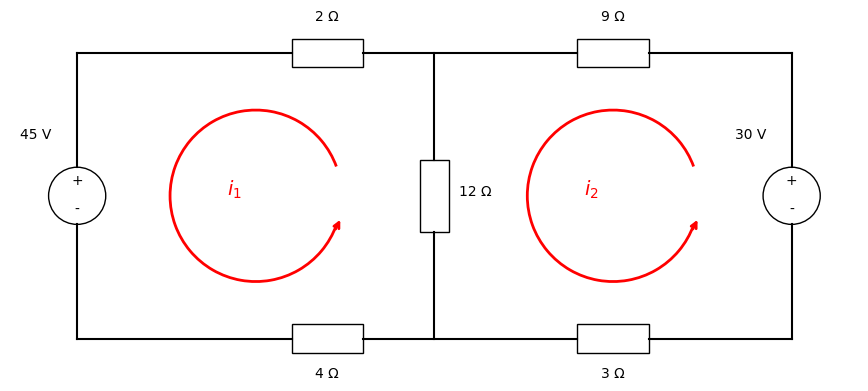

In [37]:
# TEST CELL
from matplotlib.patches import Rectangle, Circle, Arc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))

# Wires
ax.plot([0,3],[4,4],'k')
ax.plot([4,7],[4,4],'k')
ax.plot([8,10],[4,4],'k')
ax.plot([0,3],[0,0],'k')
ax.plot([4,7],[0,0],'k')
ax.plot([8,10],[0,0],'k')

# Voltage source branches (no wire through source)
ax.plot([0,0],[0,1.6],'k')
ax.plot([0,0],[2.4,4],'k')
ax.plot([10,10],[0,1.6],'k')
ax.plot([10,10],[2.4,4],'k')

ax.add_patch(Circle((0,2),0.4,fill=False))
ax.add_patch(Circle((10,2),0.4,fill=False))
ax.text(-0.8,2.8,'45 V')
ax.text(9.2,2.8,'30 V')
ax.text(0,2.15,'+',ha='center')
ax.text(0,1.75,'-',ha='center')
ax.text(10,2.15,'+',ha='center')
ax.text(10,1.75,'-',ha='center')

# Center branch
ax.plot([5,5],[0,1.5],'k')
ax.plot([5,5],[2.5,4],'k')

# European resistors with values
ax.add_patch(Rectangle((3,3.8),1,0.4,fill=False))
ax.text(3.5,4.45,'2 Ω',ha='center')

ax.add_patch(Rectangle((7,3.8),1,0.4,fill=False))
ax.text(7.5,4.45,'9 Ω',ha='center')

ax.add_patch(Rectangle((3,-0.2),1,0.4,fill=False))
ax.text(3.5,-0.55,'4 Ω',ha='center')

ax.add_patch(Rectangle((7,-0.2),1,0.4,fill=False))
ax.text(7.5,-0.55,'3 Ω',ha='center')

ax.add_patch(Rectangle((4.8,1.5),0.4,1.0,fill=False))
ax.text(5.35,2.0,'12 Ω')

# Mesh current loops
arc1 = Arc((2.5,2),2.4,2.4,theta1=20,theta2=340,color='red',lw=2)
ax.add_patch(arc1)
ax.annotate('', xy=(3.7,1.7), xytext=(3.6,1.5),
            arrowprops=dict(arrowstyle='->',color='red',lw=2))
ax.text(2.1,2.0,'$i_1$',color='red',fontsize=14)

arc2 = Arc((7.5,2),2.4,2.4,theta1=20,theta2=340,color='red',lw=2)
ax.add_patch(arc2)
ax.annotate('', xy=(8.7,1.7), xytext=(8.6,1.5),
            arrowprops=dict(arrowstyle='->',color='red',lw=2))
ax.text(7.1,2.0,'$i_2$',color='red',fontsize=14)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()


1. In the example above the n mesh currents is n = 2, we assign $i_1$ and $i_2$ to the mesh currents. 
2. Apply KVL on mesh 1:

$$-45 + 2\cdot i_1 + 12(i_1-i2) + 4\cdot i_1 = 0 $$

$$ 18\cdot i_1 -12\cdot i_2= 45 $$

   $$6\cdot i_1 -4\cdot i_2 = 15$$
   Apply KVL on mesh 2: 
   $$ 12(i_2-i_1) +9\cdot i_2 + 30 + 3\cdot i_2 = 0$$
   
$$ -12\cdot i_1 + 24\cdot i_2 = -30 $$
                       
$$ -2\cdot i_1 + 4 \cdot i_2 = -5 $$
We have to sets of equations
$$
\begin{aligned}
6i_1 - 4i_2 &= 15 \\
-2i_1 + 4i_2 &= -5
\end{aligned}
$$

There are 3 methods that can solve this:
1. Substitution method
2. Cramers rule
3. Matrix inversion

We can put on standard matrix form **Ai=b**

$$
\begin{bmatrix}
6 & -4 \\
-2 & 4
\end{bmatrix}
\begin{bmatrix}
i_1 \\
i_2
\end{bmatrix}
=
\begin{bmatrix}
15\\
-5
\end{bmatrix}$$ 

And solve by matrix inversion:

In [39]:
import numpy as np
A = np.array([[6, -4],[-2,4]])
b = np.array([[15],[-5]])
A_inv = np.linalg.inv(A)
i = A_inv @ b
print('Given matrix A:', A)
print('The first mesh i_1=', np.round(i[0,0],2))
print('The second mesh i_2=', np.round(i[1,0]))

Given matrix A: [[ 6 -4]
 [-2  4]]
The first mesh i_1= 2.5
The second mesh i_2= -0.0


## Supermesh

If two meshes share the same current source, we have a supermesh.

When a current source is present
If a current source lies between two meshes, you cannot write KVL through that branch because the source voltage is unknown.
Instead:

- Combine the two meshes into a supermesh.
- Write one KVL equation around the outer boundary.
- Write a current constraint equation from the current source.

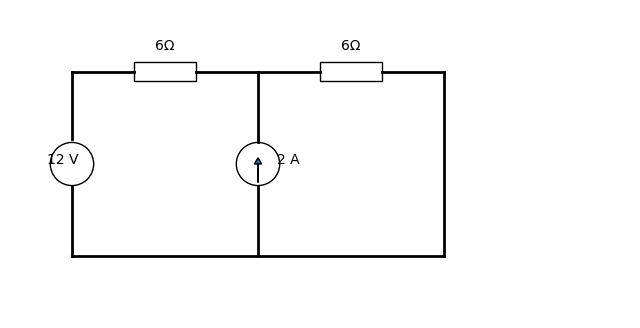

In [12]:
# TEST CELL
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
ax.set_xlim(0,10)
ax.set_ylim(0,5)
ax.axis('off')

# Wires
ax.plot([1,1],[1,2.15],'k',lw=2)
ax.plot([1,1],[2.9,4],'k',lw=2)
ax.plot([1,7],[1,1],'k',lw=2)

# Top path
ax.plot([1,2],[4,4],'k',lw=2)
ax.plot([3,4],[4,4],'k',lw=2)
ax.plot([4,5],[4,4],'k',lw=2)
ax.plot([6,7],[4,4],'k',lw=2)
#ax.plot([7,8],[4,4],'k',lw=2)

# Resistors
ax.add_patch(plt.Rectangle((2,3.85),1,0.3,fill=False))
ax.text(2.5,4.35,'6Ω',ha='center')
ax.add_patch(plt.Rectangle((5,3.85),1,0.3,fill=False))
ax.text(5.5,4.35,'6Ω',ha='center')

# Voltage source
circle = plt.Circle((1,2.5),0.35,fill=False)
ax.add_patch(circle)
ax.text(0.6,2.5,'12 V')

# Current source
circle2 = plt.Circle((4,2.5),0.35,fill=False)
ax.add_patch(circle2)
ax.arrow(4,2.2,0,0.4,head_width=0.12,head_length=0.1,length_includes_head=True)
ax.text(4.3,2.5,'2 A')
ax.plot([4,4],[1,2.15],'k',lw=2)
ax.plot([4,4],[2.85,4],'k',lw=2)


# bottom wire
ax.plot([7,7],[4,1],'k',lw=2)


plt.show()

Eq 1, KVL on the outer boundary

$$ -12 + 6\cdot i_1 + 6\cdot i_2  = 0 $$ 

$$ 6\cdot i_1 + 6\cdot i_2 = 12 $$

Eq 2, KCL:

$$ i_2 = i_1 + 2 $$

$$ -i_1 + i_2 = 2 $$

$$
\begin{bmatrix}
6 & 6 \\
-1 & 1
\end{bmatrix}
\begin{bmatrix}
i_1 \\
i_2
\end{bmatrix}
=
\begin{bmatrix}
12\\
2
\end{bmatrix}
$$

In [13]:
import numpy as np
A = np.array([[6, 6],[-1,1]])
b = np.array([[12],[2]])
A_inv = np.linalg.inv(A)
i = A_inv @ b
print('Given matrix A:', A)
print('The first mesh i_1=', np.round(i[0,0],2))
print('The second mesh i_2=', np.round(i[1,0],2))

Given matrix A: [[ 6  6]
 [-1  1]]
The first mesh i_1= -0.0
The second mesh i_2= 2.0


### Current source in mesh

When a current source exists only in one mesh we set, $i_2=-5 A$ and write a mesh equation for the other mesh in the usual way.

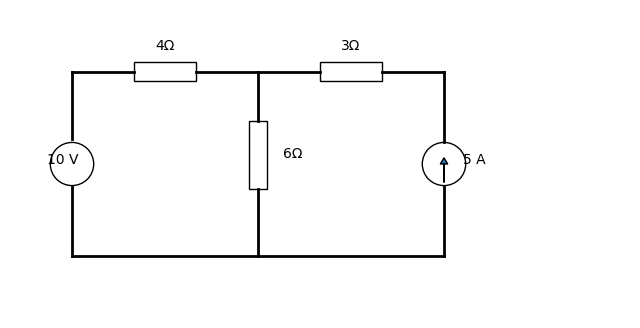

In [31]:
# TEST CELL
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
ax.set_xlim(0,10)
ax.set_ylim(0,5)
ax.axis('off')

# Wires
ax.plot([1,1],[1,2.15],'k',lw=2)
ax.plot([1,1],[2.9,4],'k',lw=2)
ax.plot([1,7],[1,1],'k',lw=2)

# Top path
ax.plot([1,2],[4,4],'k',lw=2)
ax.plot([3,4],[4,4],'k',lw=2)
ax.plot([4,5],[4,4],'k',lw=2)
ax.plot([6,7],[4,4],'k',lw=2)


# Resistors
ax.add_patch(plt.Rectangle((2,3.85),1,0.3,fill=False))
ax.text(2.5,4.35,'4Ω',ha='center')
ax.add_patch(plt.Rectangle((5,3.85),1,0.3,fill=False))
ax.text(5.5,4.35,'3Ω',ha='center')

# Voltage source
circle = plt.Circle((1,2.5),0.35,fill=False)
ax.add_patch(circle)
ax.text(0.6,2.5,'10 V')

# middle resistor
ax.plot([4,4],[4,3.2],'k',lw=2)
ax.add_patch(plt.Rectangle((3.85,2.1),0.3,1.1,fill=False))
ax.plot([4,4],[2.1,1],'k',lw=2)
ax.text(4.4,2.6,'6Ω')

# Current source
circle2 = plt.Circle((7,2.5),0.35,fill=False)
ax.add_patch(circle2)
ax.arrow(7,2.2,0,0.4,head_width=0.12,head_length=0.1,length_includes_head=True)
ax.text(7.3,2.5,'5 A')
ax.plot([7,7],[1,2.15],'k',lw=2)
ax.plot([7,7],[2.85,4],'k',lw=2)

plt.show()

$$ -10 + 4\cdot i_1 + 6(i_1-i_2) = 0 $$

$$ -10 + 4\cdot i_1 + 6(i_1-(-5)) = 0 $$

$$ -10 + 4\cdot i_1 + 6(i_1+5) = 0 $$

$$10\cdot i_1 = -30+10 $$

$$10\cdot i_1 = -20 $$

$$i_1 = \frac{-20}{10}= -2A $$

$$i_2 = -5A$$